<a href="https://colab.research.google.com/github/pzedros/metodos_numericos/blob/main/trabalho_5_metodos1_questao1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regressão Linear:
y = -4.8987 + 2.6206x
R² = 0.7225
Erro padrão Syx = 1.8844

Regressão Quadrática:
y = -5.8413 + 4.3608x + -0.4972x²
R² = 0.7464
Erro padrão Syx = 1.8748

Regressão Cúbica:
y = -8.6558 + 16.0727x + -9.1574x² + 1.6496x³
R² = 0.9752
Erro padrão Syx = 0.6125



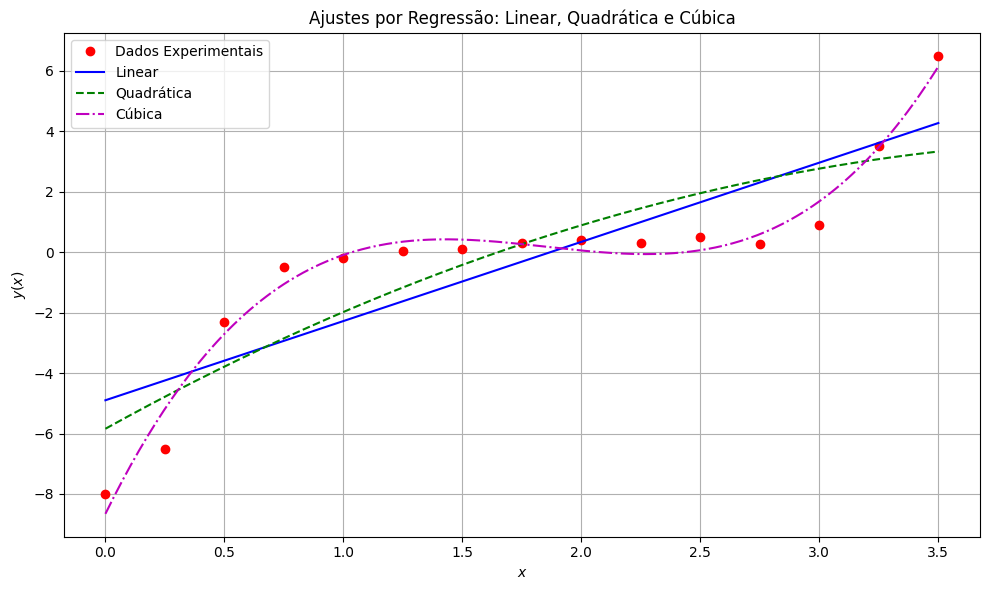

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dados
x = np.array([0.00, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00, 2.25, 2.50, 2.75, 3.00, 3.25, 3.50])
y = np.array([-8.00, -6.50, -2.30, -0.50, -0.20, 0.05, 0.10, 0.30, 0.40, 0.30, 0.50, 0.26, 0.90, 3.50, 6.50])
n = len(x)
y_medio = np.mean(y)

# ---- (a) Regressão Linear ----
Sx = np.sum(x)
Sx2 = np.sum(x**2)
Sy = np.sum(y)
Sxy = np.sum(x * y)

A1 = np.array([[n, Sx], [Sx, Sx2]])
b1 = np.array([[Sy], [Sxy]])

a1 = np.linalg.inv(A1) @ b1
y_lin = a1[0] + a1[1] * x

Sr_lin = np.sum((y - y_lin.ravel())**2)
St = np.sum((y - y_medio)**2)
R2_lin = (St - Sr_lin) / St
Syx_lin = np.sqrt(Sr_lin / (n - 2))

# ---- (b1) Regressão Quadrática ----
Sx3 = np.sum(x**3)
Sx4 = np.sum(x**4)
Sx2y = np.sum((x**2) * y)

A2 = np.array([[n, Sx, Sx2],
               [Sx, Sx2, Sx3],
               [Sx2, Sx3, Sx4]])
b2 = np.array([[Sy], [Sxy], [Sx2y]])

a2 = np.linalg.inv(A2) @ b2
y_quad = a2[0] + a2[1]*x + a2[2]*x**2

Sr_quad = np.sum((y - y_quad.ravel())**2)
R2_quad = (St - Sr_quad) / St
Syx_quad = np.sqrt(Sr_quad / (n - 3))

# ---- (b2) Regressão Cúbica ----
Sx5 = np.sum(x**5)
Sx6 = np.sum(x**6)
Sx3y = np.sum((x**3) * y)

A3 = np.array([[n, Sx, Sx2, Sx3],
               [Sx, Sx2, Sx3, Sx4],
               [Sx2, Sx3, Sx4, Sx5],
               [Sx3, Sx4, Sx5, Sx6]])
b3 = np.array([[Sy], [Sxy], [Sx2y], [Sx3y]])

a3 = np.linalg.inv(A3) @ b3
y_cub = a3[0] + a3[1]*x + a3[2]*x**2 + a3[3]*x**3

Sr_cub = np.sum((y - y_cub.ravel())**2)
R2_cub = (St - Sr_cub) / St
Syx_cub = np.sqrt(Sr_cub / (n - 4))

# ---- Impressão dos resultados ----
print("Regressão Linear:")
print(f"y = {a1[0][0]:.4f} + {a1[1][0]:.4f}x")
print(f"R² = {R2_lin:.4f}")
print(f"Erro padrão Syx = {Syx_lin:.4f}\n")

print("Regressão Quadrática:")
print(f"y = {a2[0][0]:.4f} + {a2[1][0]:.4f}x + {a2[2][0]:.4f}x²")
print(f"R² = {R2_quad:.4f}")
print(f"Erro padrão Syx = {Syx_quad:.4f}\n")

print("Regressão Cúbica:")
print(f"y = {a3[0][0]:.4f} + {a3[1][0]:.4f}x + {a3[2][0]:.4f}x² + {a3[3][0]:.4f}x³")
print(f"R² = {R2_cub:.4f}")
print(f"Erro padrão Syx = {Syx_cub:.4f}\n")

# ---- Gráficos ----
x_plot = np.linspace(min(x), max(x), 300)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'or', label='Dados Experimentais')

plt.plot(x_plot, a1[0] + a1[1]*x_plot, 'b-', label='Linear')
plt.plot(x_plot, a2[0] + a2[1]*x_plot + a2[2]*x_plot**2, 'g--', label='Quadrática')
plt.plot(x_plot, a3[0] + a3[1]*x_plot + a3[2]*x_plot**2 + a3[3]*x_plot**3, 'm-.', label='Cúbica')

plt.xlabel('$x$')
plt.ylabel('$y(x)$')
plt.title('Ajustes por Regressão: Linear, Quadrática e Cúbica')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
